## WEEK -03 EDA

The objective of this project is to work on real-world dataset and  understand the importance of data cleaning and exploratory data analysis (EDA).Data cleaning help to improve the quality of data by removing missing values ,  removing duplicate values  , correcting  datatypes and filling the msiising values . This process is also known as data pre-processing  .In this project EDA  is performed to identidied  patterns  , trends and meaningfull insights from  data. The dataset used for this analysis is the netflix_titles dataset obtained from Kaggle.



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    df = pd.read_csv("netflix_titles.csv")
    print("Dataset loaded successfully")
except FileNotFoundError:
    print("ERROR: netflix_titles.csv not found. Check the file path.")


Dataset loaded successfully


## Dataset Preview:
The Netflix dataset contains information about movies and TV shows available
on Netflix, including title, director, cast, country, release year,
rating, duration, date_added, listed_in and genre.


In [2]:

def preview_dataset(df):
    """Print a quick overview of the dataset."""
    print("First 5 rows:")
    print(df.head())
    print(f"\nShape: {df.shape[0]} rows × {df.shape[1]} columns")
    print(f"\nColumns: {df.columns.tolist()}")
    print("\nData Types & Non-Null Counts:")
    df.info()

preview_dataset(df)

First 5 rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

## Remove Duplicates:
Duplicate rows need to be removed becuase it affect analysis.As we see in our dataset there is no duplicate values found.

In [3]:
def remove_duplicates(df):

    duplicates_before = df.duplicated().sum()
    print(f"Duplicate rows before removal: {duplicates_before}")
    df = df.drop_duplicates()
    duplicates_after = df.duplicated().sum()
    print(f"Duplicate rows after removal: {duplicates_after}")

    return df
df = remove_duplicates(df)

Duplicate rows before removal: 0
Duplicate rows after removal: 0


## Handle Missing Values:
Some columns in the dataset had missing values. These missing values were handled by filling text-based columns with Unknown to avoid losing data. A few duration values were also found in the rating column by mistake and were moved to the correct column before performing the analysis.

In [ ]:
print("Missing values before cleaning:")
print(df.isnull().sum())
print()

invalid_ratings = ["74 min", "84 min", "66 min"]
misplaced_mask = df["rating"].isin(invalid_ratings)
df.loc[misplaced_mask, "duration"] = df.loc[misplaced_mask, "rating"]
df.loc[misplaced_mask, "rating"] = np.nan

df.fillna({
    "director": "Unknown",
    "cast": "Unknown",
    "country": "Unknown"
}, inplace=True)

df["rating"] = df["rating"].fillna(df["rating"].mode()[0])

df["duration"] = df["duration"].fillna(df["duration"].mode()[0])

df.dropna(subset=["date_added"], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values before cleaning:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Missing values after cleaning:
show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64


## Rename Columns Properly:

In [5]:
def standardize_column_names(df):
    df.columns = df.columns.str.lower().str.strip()
    print("Column names after standardization:")
    print(df.columns.tolist())
    return df

df = standardize_column_names(df)

Column names after standardization:
['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added', 'release_year', 'rating', 'duration', 'listed_in', 'description']


## Convert Data Types
Some columns were not stored in the correct format when the dataset was loaded. For example, the date_added column was read as text (string) instead of a date. Therefore, it was converted to datetime format so that year-wise and month-wise analysis could be performed accurately.


In [6]:

df["date_added"] = pd.to_datetime(df["date_added"], errors="coerce")
df.dropna(subset=["date_added"], inplace=True)

df["year_added"] = df["date_added"].dt.year
df["month_added"] = df["date_added"].dt.month

df["duration_value"] = df["duration"].str.extract(r"(\d+)").astype(float)
df["duration_unit"] = df["duration"].str.extract(r"([A-Za-z]+)")

print("Updated dtypes:")
print(df[["date_added", "year_added", "month_added", "duration_value", "duration_unit"]].dtypes)

Updated dtypes:
date_added        datetime64[us]
year_added                 int32
month_added                int32
duration_value           float64
duration_unit                str
dtype: object


## Detect Outliers
Outliers are values that are very different from most of the data. These  values can affect the results of the analysis, so they should be identified and checked carefully. The IQR method identifies values that fall far outside the normal range

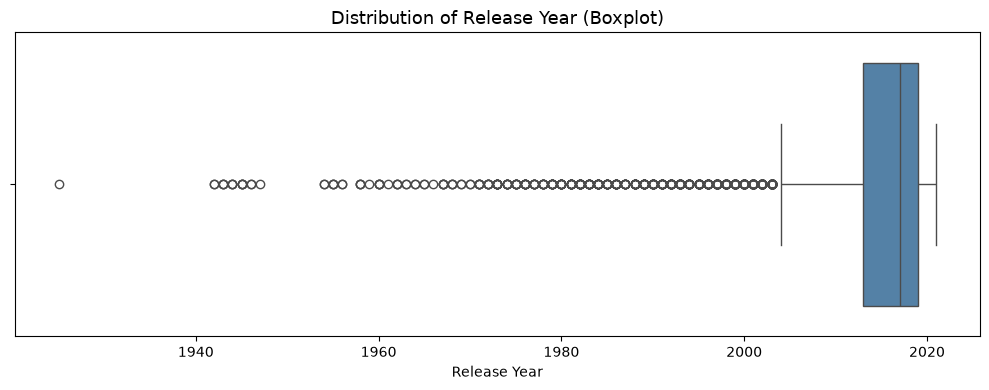

Outliers detected in 'release_year': 711
Earliest release year in outliers: 1925


In [7]:

plt.figure(figsize=(10, 4))
sns.boxplot(x=df["release_year"], color="steelblue")
plt.title("Distribution of Release Year (Boxplot)", fontsize=13)
plt.xlabel("Release Year")
plt.tight_layout()
plt.show()

Q1 = df["release_year"].quantile(0.25)
Q3 = df["release_year"].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df["release_year"] < Q1 - 1.5 * IQR) | (df["release_year"] > Q3 + 1.5 * IQR)]
print(f"Outliers detected in 'release_year': {len(outliers)}")
print(f"Earliest release year in outliers: {outliers['release_year'].min()}")



## Exploratory Data Analysis (EDA):
EDA is the process of examining and understanding what the data contains by cleaning it, identifying patterns and trends, finding meaningful insights, and analyzing relationships between variables to better understand the dataset.

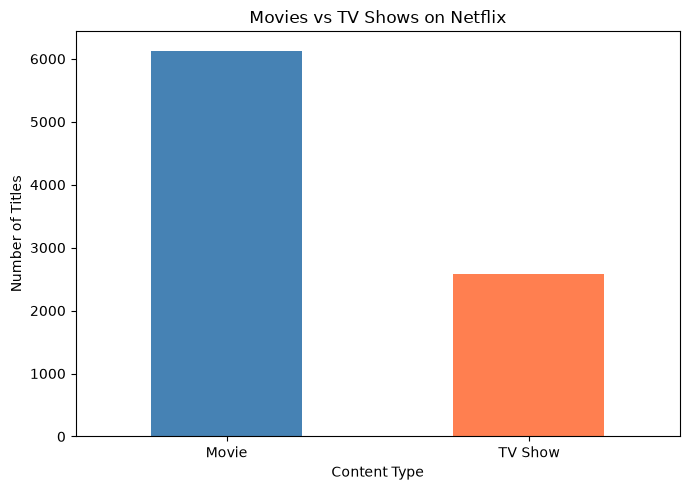

In [8]:
#Movies vs TV Shows 

plt.figure(figsize=(7, 5))
df["type"].value_counts().plot(kind="bar", color=["steelblue", "coral"])
plt.title("Movies vs TV Shows on Netflix")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

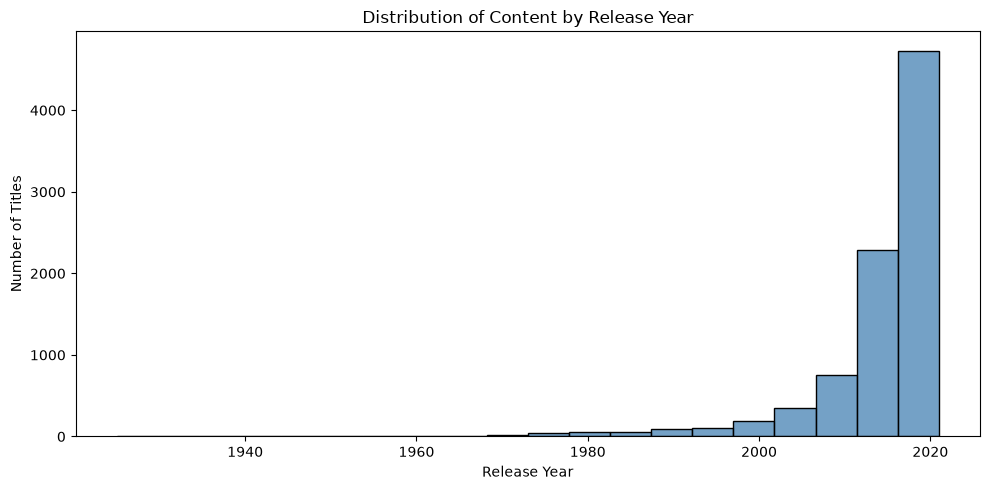

In [9]:
#Release Year

plt.figure(figsize=(10, 5))
sns.histplot(df["release_year"], bins=20, color="steelblue")
plt.title("Distribution of Content by Release Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

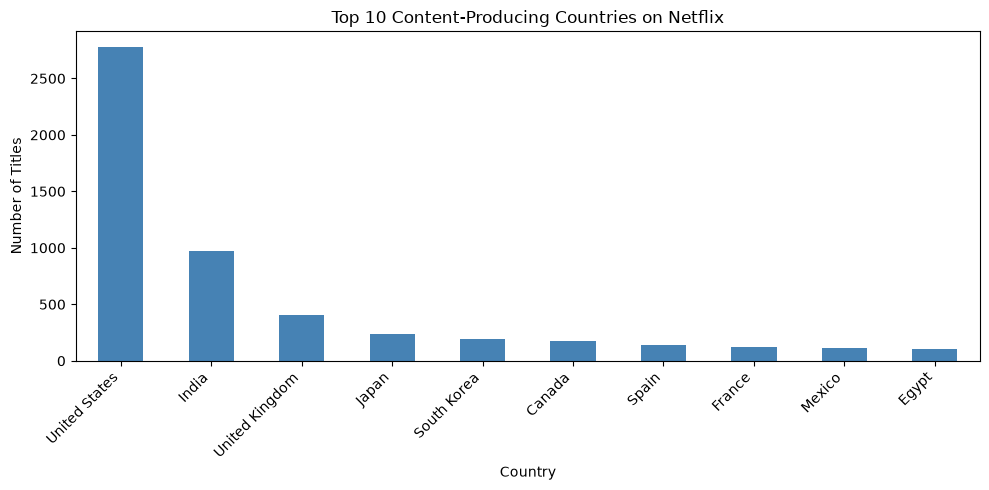

In [10]:
#Top Countries

top_countries = df[df["country"] != "Unknown"]["country"].value_counts().head(10)
plt.figure(figsize=(10, 5))
top_countries.plot(kind="bar", color="steelblue")
plt.title("Top 10 Content-Producing Countries on Netflix")
plt.xlabel("Country")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

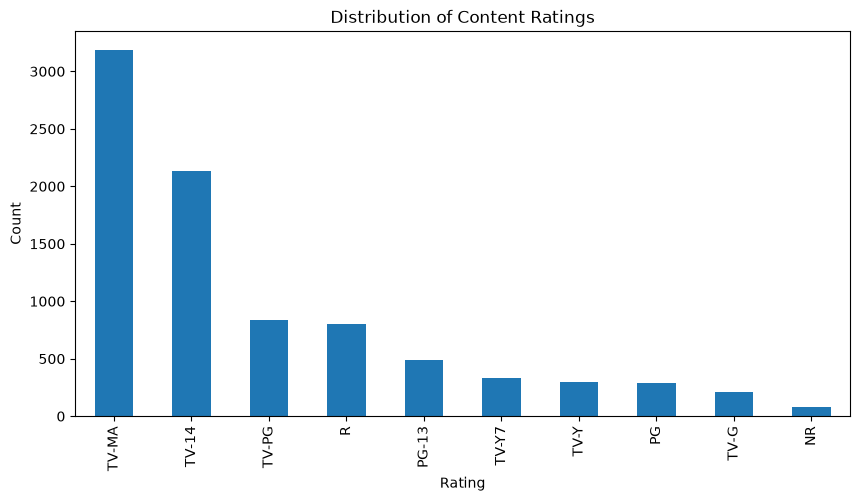

In [11]:
#Rating

plt.figure(figsize=(10,5))
df["rating"].value_counts().head(10).plot(kind="bar")
plt.title("Distribution of Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1328
Documentaries                869
Action & Adventure           859
Independent Movies           756
TV Dramas                    739
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


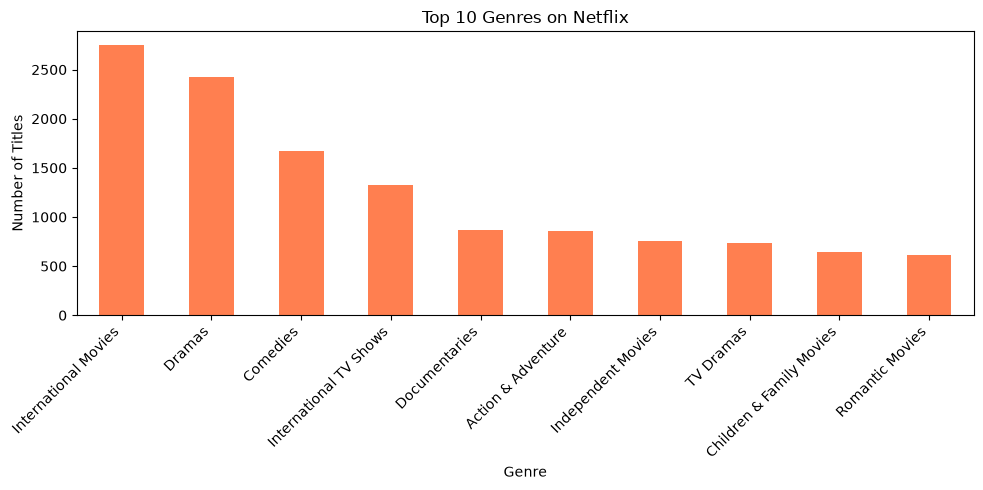

In [12]:
#Genres — explode to count individually
genres = df["listed_in"].str.split(",").explode().str.strip()

top_genres = genres.value_counts()[:10]
print(top_genres)

plt.figure(figsize=(10, 5))
top_genres.plot(kind="bar", color="coral")
plt.title("Top 10 Genres on Netflix")
plt.xlabel("Genre")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

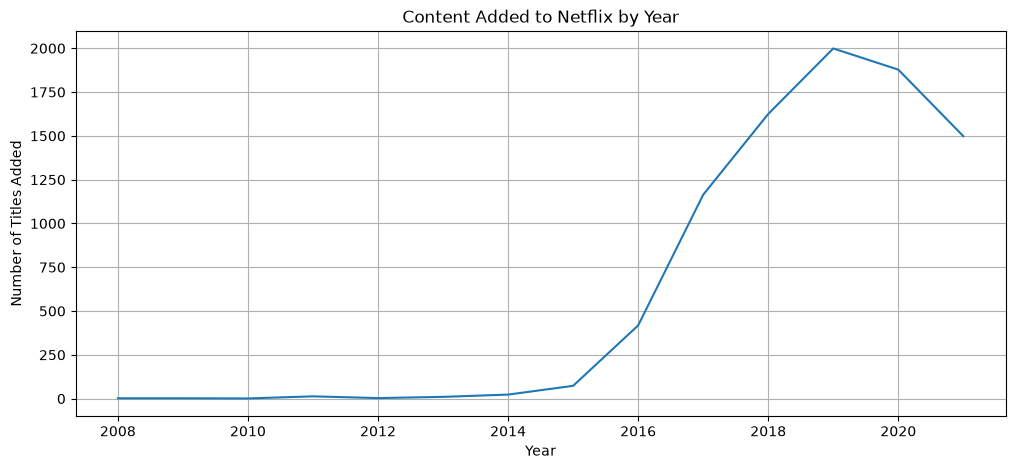

In [13]:
#Content Added to Netflix Per Year

df["year_added"] = df["date_added"].dt.year

plt.figure(figsize=(12,5))
df["year_added"].value_counts().sort_index().plot(kind="line")
plt.title("Content Added to Netflix by Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.grid(True)
plt.show()

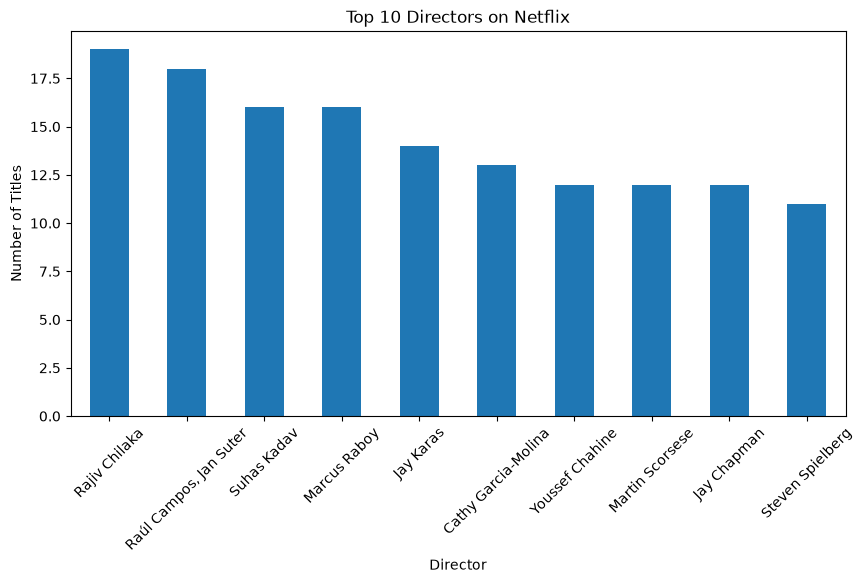

In [14]:
#Top 10 Directors on Netflix

top_directors = df[df["director"] != "Unknown"]["director"].value_counts().head(10)

plt.figure(figsize=(10,5))
top_directors.plot(kind="bar")
plt.title("Top 10 Directors on Netflix")
plt.xlabel("Director")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.show()

## Statistics summary:
Summary statistics are used to get a quick overview of the data such as average values, minimum values, maximum values, spread of data, and frequency.

In [15]:
def generate_summary_statistics(df):

    print("Dataset Shape:")
    print(df.shape)
    print()
    print("Summary Statistics:")
    print(df.describe(include="all"))
    print()

    return df
generate_summary_statistics(df)

Dataset Shape:
(8709, 16)

Summary Statistics:
       show_id   type                 title director     cast        country  \
count     8709   8709                  8709     8709     8709           8709   
unique    8709      2                  8709     4525     7606            746   
top         s1  Movie  Dick Johnson Is Dead  Unknown  Unknown  United States   
freq         1   6131                     1     2541      817           2778   
mean       NaN    NaN                   NaN      NaN      NaN            NaN   
min        NaN    NaN                   NaN      NaN      NaN            NaN   
25%        NaN    NaN                   NaN      NaN      NaN            NaN   
50%        NaN    NaN                   NaN      NaN      NaN            NaN   
75%        NaN    NaN                   NaN      NaN      NaN            NaN   
max        NaN    NaN                   NaN      NaN      NaN            NaN   
std        NaN    NaN                   NaN      NaN      NaN            

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,duration_value,duration_unit
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,90.0,min
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021,9,2.0,Seasons
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021,9,1.0,Season
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021,9,1.0,Season
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021,9,2.0,Seasons
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,2019-11-20,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019,11,158.0,min
8803,s8804,TV Show,Zombie Dumb,Unknown,Unknown,Unknown,2019-07-01,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019,7,2.0,Seasons
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,2019-11-01,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019,11,88.0,min
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,2020-01-11,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020,1,88.0,min


In [16]:
df.to_csv(
"cleaned_netflixx.csv",
index=False
)
print()
print(
"Cleaned Dataset Saved"
)




Cleaned Dataset Saved


## 10 Insights :

1. From this dataset we get to know  that Netflix's library has  approximately 70% of Movies and 30% TV shows.
2. The United States produces the most content around 2500+ titles and then India with around 1000 titles.
3. TV-MA is the most common rating for adult, so TV-MA  is the top rating  , suggesting most content viewed by adults.
4. The number of titles added to Netflix grew rapidly every year from 2015 and reached its peak in 2019,after that, additions slowed down — most likely because of pandemic.
5. Dramas and International Movies are the top two genre categories on Netflix.
6. No single director has a large share of content. Even the top director has only about 19 titles out of nearly 8,800, which is a very small amount.
7. Between 2018 and 2019, Netflix was expanding aggressively into new countries just before major competitors like Disney plus and Apple TV plus  launched in late 2019.
8. While most Netflix titles were released after the year 2000, a small number of titles date back to the 1940s and 1950s, they appear as outlier.
9. A data quality issue was found where a few duration values (e.g., "74 min", "84 min") were incorrectly stored in the rating column and were corrected before analysis.
10. By splitting the duration column into a numeric part and a unit part — minutes for Movies and seasons for TV Shows — it became clear that these two content types cannot be compared using the same measure.